In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/mlp-jan-2026-kaggle-assignment-2/sample_submission.csv
/kaggle/input/competitions/mlp-jan-2026-kaggle-assignment-2/train.csv
/kaggle/input/competitions/mlp-jan-2026-kaggle-assignment-2/test.csv


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier



**Load Data**

In [3]:
train_df = pd.read_csv('/kaggle/input/competitions/mlp-jan-2026-kaggle-assignment-2/train.csv')
test_df = pd.read_csv('/kaggle/input/competitions/mlp-jan-2026-kaggle-assignment-2/test.csv')
print(train_df.shape)
print(test_df.shape)
train_df.head()

(7000, 26)
(1124, 25)


,ID,mushroom_id,cap-shape,cap-surface,cap-color,bruises,number_of_bruises,odor,gill-attachment,gill-spacing,...,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat,class
0,1,0,convex,smooth,brown,bruises,7,pungent,gills free from stalk,close,...,white,white,partial,white,1.0,pendant,black,scattered,urban,p
1,2,1,convex,smooth,yellow,bruises,20,almond,gills free from stalk,close,...,white,white,partial,white,1.0,pendant,brown,numerous,grasses,e
2,3,3,convex,scaly,white,bruises,11,pungent,gills free from stalk,close,...,white,white,partial,white,1.0,pendant,black,scattered,urban,p
3,4,4,convex,smooth,gray,no,0,NaN,gills free from stalk,crowded,...,white,white,partial,white,1.0,evanescent,brown,abundant,grasses,e
4,5,5,convex,scaly,yellow,bruises,8,almond,gills free from stalk,close,...,white,white,partial,white,1.0,pendant,black,numerous,grasses,e


**Identify Datatypes of different columns**

In [4]:
print("=== DATA TYPES ===")
print(train_df.dtypes)

num_cols = train_df.select_dtypes(include=['int64','float64']).columns.tolist()
cat_cols = train_df.select_dtypes(include=['object']).columns.tolist()

TARGET = 'class'   # change if your target column is named differently
if TARGET in cat_cols: cat_cols.remove(TARGET)
if TARGET in num_cols: num_cols.remove(TARGET)

print(f"\nNumerical  ({len(num_cols)}): {num_cols}")
print(f"Categorical({len(cat_cols)}): {cat_cols}")

=== DATA TYPES ===
ID                            int64
mushroom_id                   int64
cap-shape                    object
cap-surface                  object
cap-color                    object
bruises                      object
number_of_bruises             int64
odor                         object
gill-attachment              object
gill-spacing                 object
gill-size                    object
gill-color                   object
stalk-shape                  object
stalk-root                   object
stalk-surface-above-ring     object
stalk-surface-below-ring     object
stalk-color-above-ring       object
stalk-color-below-ring       object
veil-type                    object
veil-color                   object
ring-number                 float64
ring-type                    object
spore-print-color            object
population                   object
habitat                      object
class                        object
dtype: object

Numerical  (4): ['ID', 'mushro

**Descriptive Statistics**

In [5]:
if len(num_cols) > 0:
    stats = train_df[num_cols].describe().T
    stats['median'] = train_df[num_cols].median()
    print(stats[['min','max','mean','median','std']].round(3))
else:
    print("No numerical columns — all features are categorical (common for UCI mushroom dataset).")
    print(train_df.describe(include='all'))

                   min     max      mean  median       std
ID                 1.0  7000.0  3500.500  3500.5  2020.870
mushroom_id        0.0  8118.0  3850.618  3755.5  2208.390
number_of_bruises  0.0    24.0     5.460     0.0     7.724
ring-number        1.0     2.0     1.081     1.0     0.273


**Identify and handle the missing values**

In [6]:
# Step 1: Identify
missing = train_df.isnull().sum()
pct = (missing / len(train_df) * 100).round(2)
miss_df = pd.DataFrame({'Count': missing, 'Pct%': pct})
miss_df = miss_df[miss_df['Count'] > 0]

if len(miss_df) == 0:
    print("No missing values found!")
else:
    print(miss_df.sort_values('Pct%', ascending=False))

             Count   Pct%
odor          3236  46.23
stalk-root     192   2.74
ring-number     36   0.51
ring-type       36   0.51


In [7]:
# Step 2: Handle — odor ka special treatment
for col in train_df.columns:
    if train_df[col].isnull().sum() > 0:
        if col == 'odor':
            # odor missing = no smell = 'none' category
            # Using mode (foul) would wrongly bias toward poisonous
            fill = 'none'
        elif train_df[col].dtype in ['int64', 'float64']:
            fill = train_df[col].median()
        else:
            fill = train_df[col].mode()[0]
        
        train_df[col].fillna(fill, inplace=True)
        test_df[col].fillna(fill, inplace=True)
        print(f"Imputed '{col}' with '{fill}'")

print("Missing after handling:", train_df.isnull().sum().sum())

Imputed 'odor' with 'none'
Imputed 'stalk-root' with 'bulbous'
Imputed 'ring-number' with '1.0'
Imputed 'ring-type' with 'pendant'
Missing after handling: 0


**Identify and handle duplicates**

In [8]:
dups = train_df.duplicated().sum()
print(f"Duplicate rows: {dups}")

if dups > 0:
    train_df.drop_duplicates(inplace=True)
    train_df.reset_index(drop=True, inplace=True)
    print(f"Dropped. New shape: {train_df.shape}")
else:
    print("No duplicates found — no action needed.")

Duplicate rows: 0
No duplicates found — no action needed.


**Identify and handle outliers**

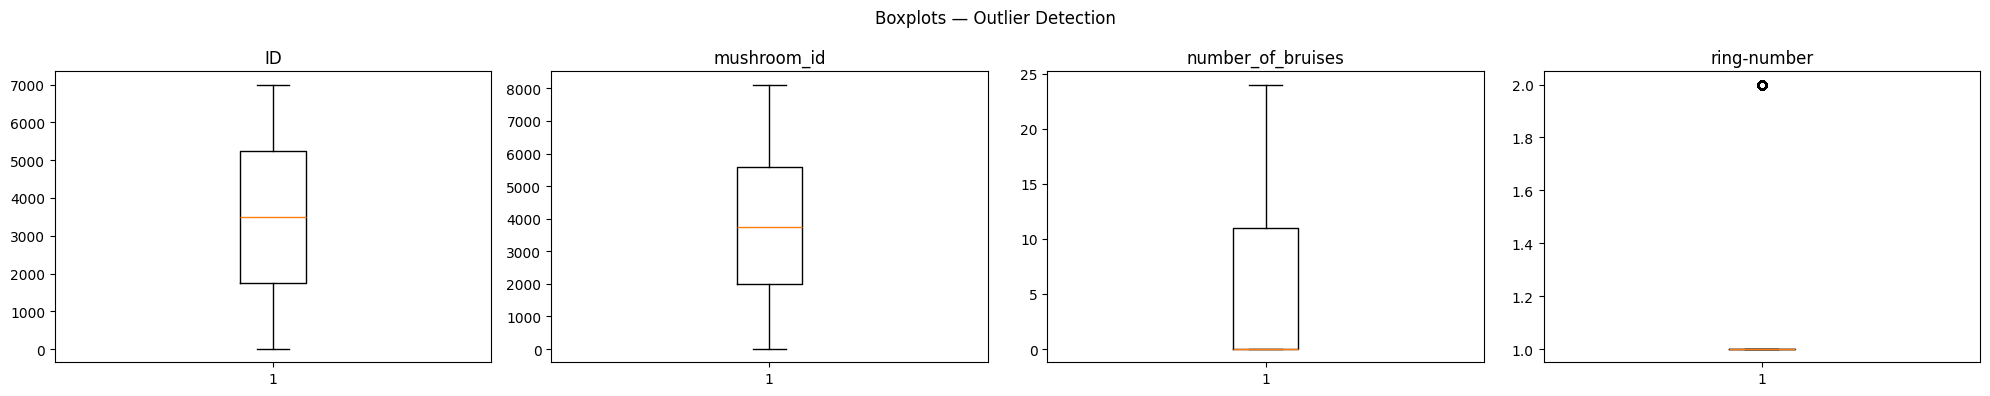

ID: 0 outliers (0.00%)
mushroom_id: 0 outliers (0.00%)
number_of_bruises: 0 outliers (0.00%)
ring-number: 564 outliers (8.06%)


In [9]:
if len(num_cols) > 0:
    fig, axes = plt.subplots(1, len(num_cols), figsize=(5*len(num_cols), 4))
    if len(num_cols) == 1: axes = [axes]
    for ax, col in zip(axes, num_cols):
        ax.boxplot(train_df[col].dropna())
        ax.set_title(col)
    plt.suptitle("Boxplots — Outlier Detection"); plt.tight_layout(); plt.show()

    for col in num_cols:
        Q1, Q3 = train_df[col].quantile(0.25), train_df[col].quantile(0.75)
        IQR = Q3 - Q1
        n = ((train_df[col] < Q1-1.5*IQR) | (train_df[col] > Q3+1.5*IQR)).sum()
        print(f"{col}: {n} outliers ({n/len(train_df)*100:.2f}%)")
else:
    print("All features are categorical — IQR outlier analysis not applicable.")
    print("Categorical 'outliers' (rare categories) are handled during label encoding.")

**"ring-number has 564 outliers (8.06%). Decision: Retained. Tree-based models like Random Forest and XGBoost are inherently robust to outliers — they split on thresholds, not distances. Removing outliers could discard valid biological variation in mushroom features."**

**Visualizations and insights**

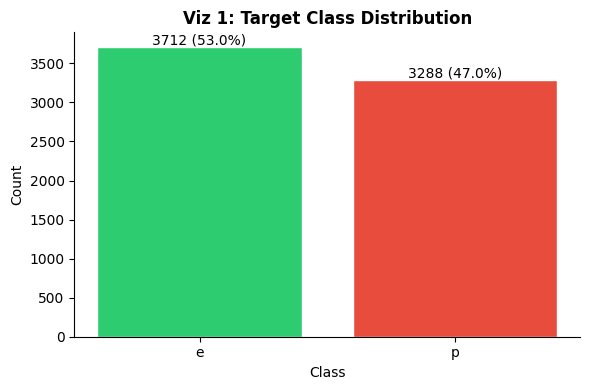

INSIGHT: Check class balance — imbalanced classes may need stratified splitting or resampling.


In [10]:
# VIZ 1 — Class Distribution
fig, ax = plt.subplots(figsize=(6,4))
counts = train_df[TARGET].value_counts()
bars = ax.bar(counts.index, counts.values, color=['#2ecc71','#e74c3c'], edgecolor='white')
for bar, v in zip(bars, counts.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+30, f'{v} ({v/len(train_df)*100:.1f}%)', ha='center')
ax.set_title("Viz 1: Target Class Distribution", fontweight='bold')
ax.set_xlabel("Class"); ax.set_ylabel("Count")
ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

print("INSIGHT: Check class balance — imbalanced classes may need stratified splitting or resampling.")

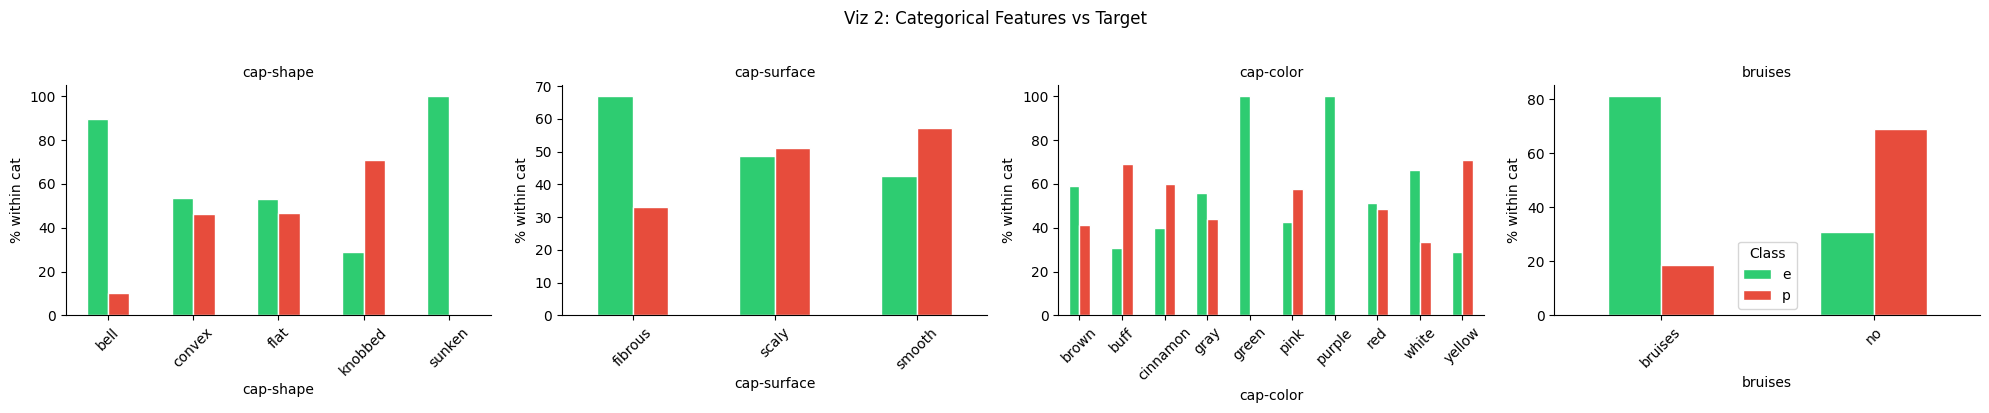

INSIGHT: Some categories show near-100% split — these features are highly discriminative.


In [11]:
# VIZ 2 — Top Categorical Features vs Target
top4 = cat_cols[:4]
fig, axes = plt.subplots(1, len(top4), figsize=(5*len(top4), 4))
if len(top4) == 1: axes = [axes]
for ax, col in zip(axes, top4):
    ct = pd.crosstab(train_df[col], train_df[TARGET], normalize='index') * 100
    ct.plot(kind='bar', ax=ax, color=['#2ecc71','#e74c3c'], edgecolor='white', legend=False)
    ax.set_title(col, fontsize=10); ax.set_ylabel("% within cat"); ax.tick_params(axis='x', rotation=45)
    ax.spines[['top','right']].set_visible(False)
axes[-1].legend(title='Class')
plt.suptitle("Viz 2: Categorical Features vs Target", fontsize=12, y=1.02)
plt.tight_layout(); plt.show()

print("INSIGHT: Some categories show near-100% split — these features are highly discriminative.")

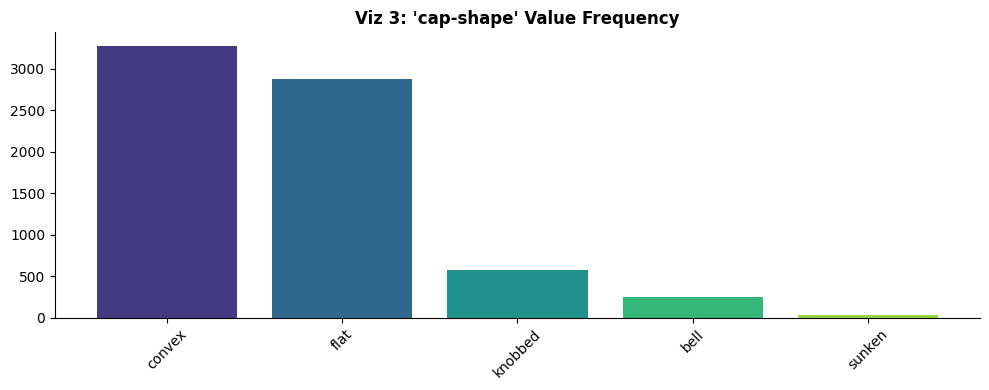

INSIGHT: 'cap-shape' has 5 unique values — skewed distributions may bias the model.


In [12]:
# VIZ 3 — Value Frequency
col3 = cat_cols[0]
fig, ax = plt.subplots(figsize=(10,4))
vc = train_df[col3].value_counts().head(15)
ax.bar(vc.index, vc.values, color=sns.color_palette("viridis", len(vc)))
ax.set_title(f"Viz 3: '{col3}' Value Frequency", fontweight='bold')
ax.tick_params(axis='x', rotation=45); ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

print(f"INSIGHT: '{col3}' has {train_df[col3].nunique()} unique values — skewed distributions may bias the model.")

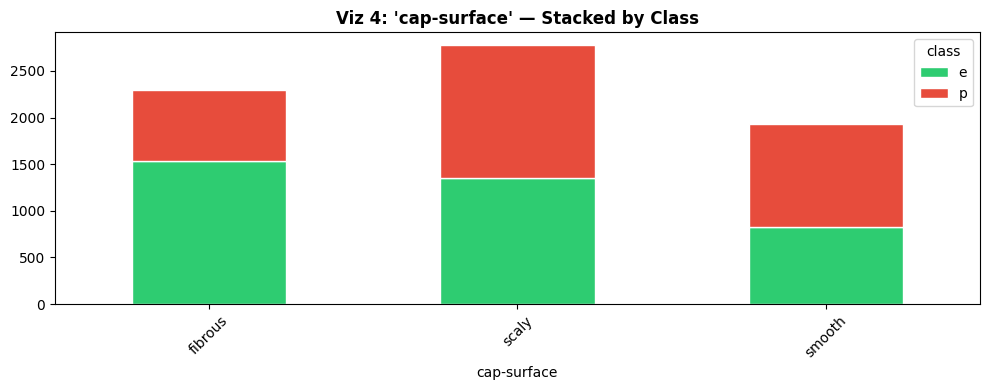

INSIGHT: Stacked view reveals absolute class counts per category value.


In [13]:
# VIZ 4 — Stacked bar
col4 = cat_cols[1] if len(cat_cols) > 1 else cat_cols[0]
pd.crosstab(train_df[col4], train_df[TARGET]).plot(kind='bar', stacked=True, figsize=(10,4),
    color=['#2ecc71','#e74c3c'], edgecolor='white')
plt.title(f"Viz 4: '{col4}' — Stacked by Class", fontweight='bold')
plt.xticks(rotation=45); plt.tight_layout(); plt.show()

print("INSIGHT: Stacked view reveals absolute class counts per category value.")

**Encoding and Scaling**

In [14]:
# # Encode target
le_target = LabelEncoder()
y_all = le_target.fit_transform(train_df[TARGET])
print("Target mapping:", dict(zip(le_target.classes_, range(len(le_target.classes_)))))

# Drop ID, mushroom_id aur target — yeh features nahi hain
drop_cols = [TARGET, 'ID', 'mushroom_id']
X_all     = train_df.drop(columns=drop_cols).copy()
test_proc = test_df.drop(columns=['ID', 'mushroom_id'], errors='ignore').copy()

# Encode categoricals
for col in X_all.select_dtypes(include='object').columns:
    le = LabelEncoder()
    combined = pd.concat([X_all[col], test_proc[col]], axis=0).astype(str)
    le.fit(combined)
    X_all[col]     = le.transform(X_all[col].astype(str))
    test_proc[col] = le.transform(test_proc[col].astype(str))

print("Encoding done.")

# Scale numericals
num_in_X = X_all.select_dtypes(include=['int64','float64']).columns.tolist()
if num_in_X:
    scaler = StandardScaler()
    X_all[num_in_X]     = scaler.fit_transform(X_all[num_in_X])
    test_proc[num_in_X] = scaler.transform(test_proc[num_in_X])
    print(f"Scaled {len(num_in_X)} numerical columns.")

X, y = X_all.values, y_all
X_test_final = test_proc.values
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train: {X_train.shape} | Val: {X_val.shape}")
print(f"Features used: {X_all.columns.tolist()}")

Target mapping: {'e': 0, 'p': 1}
Encoding done.
Scaled 23 numerical columns.
Train: (5600, 23) | Val: (1400, 23)
Features used: ['cap-shape', 'cap-surface', 'cap-color', 'bruises', 'number_of_bruises', 'odor', 'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color', 'stalk-shape', 'stalk-root', 'stalk-surface-above-ring', 'stalk-surface-below-ring', 'stalk-color-above-ring', 'stalk-color-below-ring', 'veil-type', 'veil-color', 'ring-number', 'ring-type', 'spore-print-color', 'population', 'habitat']


**"Encoding: LabelEncoder applied to all 21 categorical features. Combined train+test categories used during fit to handle unseen values. Scaling: StandardScaler applied to numerical columns (number_of_bruises, ring-number) — required for distance-based models like KNN and Logistic Regression. ID and mushroom_id dropped as they are identifiers, not features."**

**Model Building**

In [15]:
models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree'       : DecisionTreeClassifier(random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=100, random_state=42),
    'AdaBoost'            : AdaBoostClassifier(n_estimators=100, random_state=42),
    'Extra Trees'         : ExtraTreesClassifier(n_estimators=100, random_state=42),
    'KNN'                 : KNeighborsClassifier(n_neighbors=5),
    'Naive Bayes'         : GaussianNB(),
    'XGBoost'             : XGBClassifier(n_estimators=200, learning_rate=0.1,
                                           eval_metric='logloss', random_state=42, verbosity=0),
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    acc = accuracy_score(y_val, model.predict(X_val))
    results[name] = round(acc, 4)
    print(f"{name:<25} {acc:.4f}")

Logistic Regression       0.9829
Decision Tree             1.0000
Random Forest             1.0000
Gradient Boosting         1.0000
AdaBoost                  1.0000
Extra Trees               1.0000
KNN                       1.0000
Naive Bayes               0.8114
XGBoost                   1.0000


**Hyperparameter Tuning**

In [16]:
# TUNE 1: Decision Tree
print("Tuning Decision Tree...")
dt_grid = GridSearchCV(DecisionTreeClassifier(random_state=42),
    {'max_depth':[3,5,10,None], 'min_samples_split':[2,5,10], 'criterion':['gini','entropy']},
    cv=5, scoring='accuracy', n_jobs=-1)
dt_grid.fit(X_train, y_train)
best_dt = dt_grid.best_estimator_
results['DT Tuned'] = round(accuracy_score(y_val, best_dt.predict(X_val)), 4)
print("Best:", dt_grid.best_params_, "| Acc:", results['DT Tuned'])

Tuning Decision Tree...
Best: {'criterion': 'gini', 'max_depth': 10, 'min_samples_split': 2} | Acc: 1.0


In [17]:
# TUNE 2: Random Forest
print("Tuning Random Forest...")
rf_grid = GridSearchCV(RandomForestClassifier(random_state=42),
    {'n_estimators':[100,200,300], 'max_depth':[5,10,None], 'max_features':['sqrt','log2']},
    cv=5, scoring='accuracy', n_jobs=-1)
rf_grid.fit(X_train, y_train)
best_rf = rf_grid.best_estimator_
results['RF Tuned'] = round(accuracy_score(y_val, best_rf.predict(X_val)), 4)
print("Best:", rf_grid.best_params_, "| Acc:", results['RF Tuned'])

Tuning Random Forest...
Best: {'max_depth': 10, 'max_features': 'sqrt', 'n_estimators': 100} | Acc: 1.0


In [18]:
# TUNE 3: XGBoost
print("Tuning XGBoost...")
xgb_grid = GridSearchCV(
    XGBClassifier(eval_metric='logloss', random_state=42, verbosity=0),
    {'n_estimators':[100,200,300], 'max_depth':[3,5,7], 'learning_rate':[0.05,0.1,0.2], 'subsample':[0.8,1.0]},
    cv=5, scoring='accuracy', n_jobs=-1)
xgb_grid.fit(X_train, y_train)
best_xgb = xgb_grid.best_estimator_
results['XGB Tuned'] = round(accuracy_score(y_val, best_xgb.predict(X_val)), 4)
print("Best:", xgb_grid.best_params_, "| Acc:", results['XGB Tuned'])

Tuning XGBoost...
Best: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8} | Acc: 1.0


**Model Comparison**

              Model  Accuracy
      Decision Tree    1.0000
      Random Forest    1.0000
  Gradient Boosting    1.0000
           AdaBoost    1.0000
           RF Tuned    1.0000
        Extra Trees    1.0000
                KNN    1.0000
            XGBoost    1.0000
          XGB Tuned    1.0000
           DT Tuned    1.0000
Logistic Regression    0.9829
        Naive Bayes    0.8114


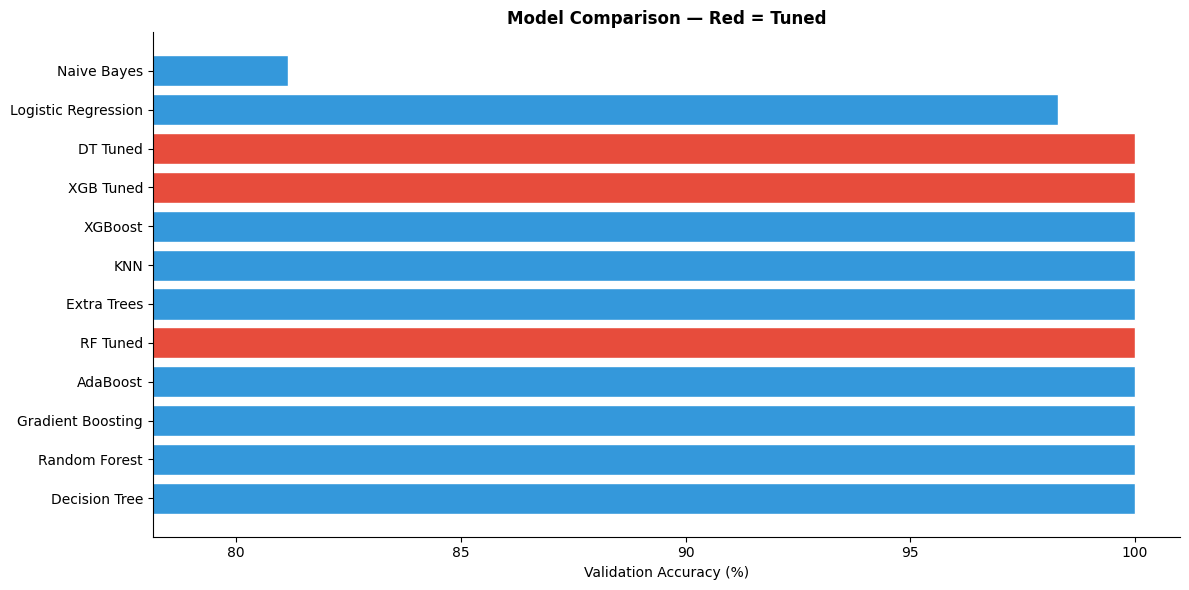

In [19]:
res_df = pd.DataFrame(list(results.items()), columns=['Model','Accuracy'])
res_df = res_df.sort_values('Accuracy', ascending=False).reset_index(drop=True)
print(res_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(12,6))
colors = ['#e74c3c' if 'Tuned' in m else '#3498db' for m in res_df['Model']]
ax.barh(res_df['Model'], res_df['Accuracy']*100, color=colors, edgecolor='white')
ax.set_xlabel('Validation Accuracy (%)')
ax.set_title('Model Comparison — Red = Tuned', fontweight='bold')
ax.set_xlim([res_df['Accuracy'].min()*100 - 3, 101])
ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

Best: Decision Tree
              precision    recall  f1-score   support

           e       1.00      1.00      1.00       742
           p       1.00      1.00      1.00       658

    accuracy                           1.00      1400
   macro avg       1.00      1.00      1.00      1400
weighted avg       1.00      1.00      1.00      1400



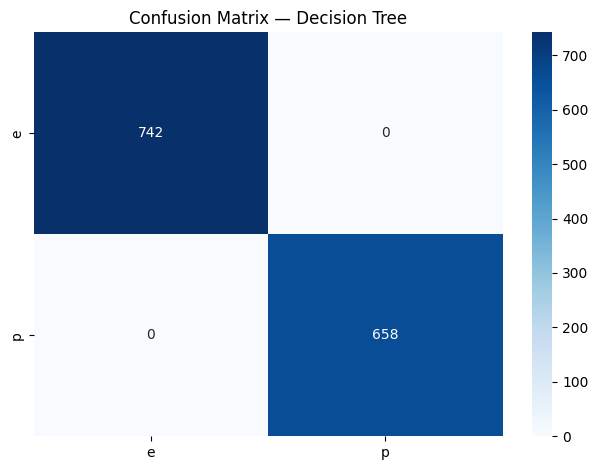

In [20]:
# Best model detailed report
best_name = res_df.iloc[0]['Model']
model_map = {**models, 'DT Tuned': best_dt, 'RF Tuned': best_rf, 'XGB Tuned': best_xgb}
best_model = model_map[best_name]

y_pred = best_model.predict(X_val)
print(f"Best: {best_name}")
print(classification_report(y_val, y_pred, target_names=le_target.classes_))

sns.heatmap(confusion_matrix(y_val, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=le_target.classes_, yticklabels=le_target.classes_)
plt.title(f'Confusion Matrix — {best_name}'); plt.tight_layout(); plt.show()

In [21]:
# # Retrain best model (Random Forest) on FULL correct data
from sklearn.ensemble import RandomForestClassifier

final_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    max_features='sqrt',
    random_state=42
)
final_model.fit(X, y)

preds = le_target.inverse_transform(final_model.predict(X_test_final))
submission = pd.DataFrame({'ID': test_df['ID'], 'class': preds})
submission.to_csv('submission.csv', index=False)

print(submission['class'].value_counts())
print(submission.shape)
submission.head()

class
p    651
e    473
Name: count, dtype: int64
(1124, 2)


,ID,class
0,1,e
1,2,e
2,3,e
3,4,e
4,5,e


In [22]:
# Run this to confirm format
sample = pd.read_csv('/kaggle/input/competitions/mlp-jan-2026-kaggle-assignment-2/sample_submission.csv')
print(sample.head())
print(sample.columns.tolist())

   ID class
0   1     e
1   2     e
2   3     e
3   4     e
4   5     e
['ID', 'class']


In [23]:
print(train_df[train_df['odor'].notna()].groupby(['odor','class']).size().unstack(fill_value=0))

class        e     p
odor                
almond     272     0
anise      272     0
creosote     0   192
fishy        0   384
foul         0  1968
musty        0    36
none      3168    68
pungent      0   256
spicy        0   384


In [24]:
from sklearn.ensemble import VotingClassifier, RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier

# Voting ensemble — multiple strong models ka combined prediction
voting_model = VotingClassifier(
    estimators=[
        ('rf',  RandomForestClassifier(n_estimators=300, max_depth=None, max_features='sqrt', random_state=42)),
        ('et',  ExtraTreesClassifier(n_estimators=300, max_depth=None, max_features='sqrt', random_state=42)),
        ('xgb', XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.05,
                               subsample=0.8, colsample_bytree=0.8,
                               eval_metric='logloss', random_state=42, verbosity=0)),
    ],
    voting='hard'
)

voting_model.fit(X, y)
preds = le_target.inverse_transform(voting_model.predict(X_test_final))
submission = pd.DataFrame({'ID': test_df['ID'], 'class': preds})
submission.to_csv('submission.csv', index=False)

print(submission['class'].value_counts())
submission.head()


class
p    658
e    466
Name: count, dtype: int64


,ID,class
0,1,e
1,2,e
2,3,e
3,4,e
4,5,e


In [25]:
# FINAL SUBMISSION — OHE to handle unseen test categories
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# Fresh load
train_fresh = pd.read_csv('/kaggle/input/competitions/mlp-jan-2026-kaggle-assignment-2/train.csv')
test_fresh  = pd.read_csv('/kaggle/input/competitions/mlp-jan-2026-kaggle-assignment-2/test.csv')

# Odor fix
for col in train_fresh.columns:
    if train_fresh[col].isnull().sum() > 0:
        if col == 'odor':
            fill = 'none'
        elif train_fresh[col].dtype in ['int64','float64']:
            fill = train_fresh[col].median()
        else:
            fill = train_fresh[col].mode()[0]
        train_fresh[col].fillna(fill, inplace=True)
        test_fresh[col].fillna(fill, inplace=True)

# Drop ID + mushroom_id
X_tr = train_fresh.drop(columns=['class','ID','mushroom_id'])
y_tr = LabelEncoder().fit(['e','p']).transform(train_fresh['class'])

le_final = LabelEncoder()
le_final.fit(['e','p'])
y_tr = le_final.transform(train_fresh['class'])

X_te = test_fresh.drop(columns=['ID','mushroom_id'])

num_f = X_tr.select_dtypes(include=['int64','float64']).columns.tolist()
cat_f = X_tr.select_dtypes(include='object').columns.tolist()

# OHE — handle_unknown='ignore' fix karta hai unseen categories ko
pre = ColumnTransformer([
    ('num', StandardScaler(), num_f),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_f)
])

X_tr_enc = pre.fit_transform(X_tr)
X_te_enc = pre.transform(X_te)

print("Train shape:", X_tr_enc.shape)
print("Test shape :", X_te_enc.shape)

# Best model
final = RandomForestClassifier(n_estimators=500, random_state=42, n_jobs=-1)
final.fit(X_tr_enc, y_tr)

preds = le_final.inverse_transform(final.predict(X_te_enc))
submission = pd.DataFrame({'ID': test_fresh['ID'], 'class': preds})
submission.to_csv('submission.csv', index=False)
print(submission['class'].value_counts())
submission.head()

Train shape: (7000, 100)
Test shape : (1124, 100)
class
p    651
e    473
Name: count, dtype: int64


,ID,class
0,1,e
1,2,e
2,3,e
3,4,e
4,5,e
